# Model training and evaluation

---
## 1. Imports

In [126]:
!pip install xgboost


In [127]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import xgboost as xgb
from matplotlib.gridspec import GridSpec
from sklearn.metrics import (
  ConfusionMatrixDisplay,
  average_precision_score,
  classification_report,
  confusion_matrix,
  f1_score,
  precision_recall_curve,
  precision_score,
  recall_score,
  roc_auc_score,
  roc_curve,
)

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

print(f"All imports OK  |  XGBoost {xgb.__version__}")

All imports OK  |  XGBoost 3.2.0


---
## 2. Hyperparameters

In [128]:
W = 30  # lookback window (steps used as input)
H = 10  # prediction horizon (steps ahead)

# Synthetic dataset
N_STEPS = 1_200  # total time steps
INCIDENT_RATE = 0.008  # Poisson arrival rate (incidents per step)
INC_DUR_MIN = 8  # minimum incident duration (steps)
INC_DUR_MAX = 20  # maximum incident duration (steps)
COOLDOWN_MIN = 5  # cooldown steps after an incident
COOLDOWN_MAX = 20
DRIFT_MAX = 8  # max drift magnitude

# Train / val / test split
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15  # remaining 0.15 -> test

# XGBoost
XGB_PARAMS = dict(
  n_estimators=300,
  max_depth=4,
  learning_rate=0.05,
  subsample=0.8,
  colsample_bytree=0.8,
  eval_metric="logloss",
  random_state=SEED
)

print(f"W={W} steps lookback  |  H={H} steps horizon  |  N={N_STEPS} total steps")

W=30 steps lookback  |  H=10 steps horizon  |  N=1200 total steps


---
## 3. Synthetic time-series generation

Three correlated metrics are simulated:
- CPU load (%) — baseline ~35%, spikes +40% during incidents
- Memory pressure (%) — baseline ~50%, rises +25% during incidents  
- Request latency (ms) — baseline ~80ms, multiplies x3 during incidents

Incident windows are drawn from a Poisson process and annotated with `incident_flag`.
A "drift" period is injected mid-series to test generalisation.

In [129]:
def generate_time_series(num_steps: int, rng: np.random.Generator) -> pd.DataFrame:
  incident_mask = np.zeros(num_steps, dtype=int)
  ramp_mask = np.zeros(num_steps, dtype=float)
  RAMP_STEPS = 10

  t = 0
  while t < num_steps:
    gap = int(rng.exponential(1 / INCIDENT_RATE))
    t += gap
    if t >= num_steps: break

    duration = int(rng.integers(INC_DUR_MIN, INC_DUR_MAX + 1))
    end = min(t + duration, num_steps)
    incident_mask[t:end] = 1

    # Add a gradual ramp-up BEFORE the incident starts
    ramp_start = max(0, t - RAMP_STEPS)
    for i in range(ramp_start, t):
        # Linearly increasing from 0 to 1
        ramp_mask[i] = (i - ramp_start) / RAMP_STEPS

    t = end + int(rng.integers(COOLDOWN_MIN, COOLDOWN_MAX + 1))

  drift = np.linspace(0, DRIFT_MAX, num_steps)

  def simulate_metric(base, spike, drift_scale, noise, low, high, ramp_mult=0.4):
    # The metric now includes: base + incident spike + subtle pre-incident ramp + noise
    return np.clip(
      base + (incident_mask * spike) + (ramp_mask * spike * ramp_mult) + drift * drift_scale + rng.normal(0, noise, num_steps),
      low,
      high,
    )

  cpu = simulate_metric(base=35, spike=40, drift_scale=0.5, noise=5, low=0, high=100)
  memory = simulate_metric(base=50, spike=25, drift_scale=0.3, noise=4, low=0, high=100)
  latency = simulate_metric(base=80, spike=200, drift_scale=2.0, noise=10, low=10, high=800)

  return pd.DataFrame({
      "cpu": cpu, "memory": memory, "latency": latency, "incident_flag": incident_mask
  })

df = generate_time_series(N_STEPS, rng)
print("New dataset generated with pre-incident ramps.")
display(df.head())

New dataset generated with pre-incident ramps.


,cpu,memory,latency,incident_flag
0,37.337547,39.393167,91.099696,0
1,30.706874,44.489965,93.580976,0
2,36.850426,42.761529,72.576860,0
3,30.215595,41.006870,73.719175,0
4,39.405596,45.226571,86.215732,0


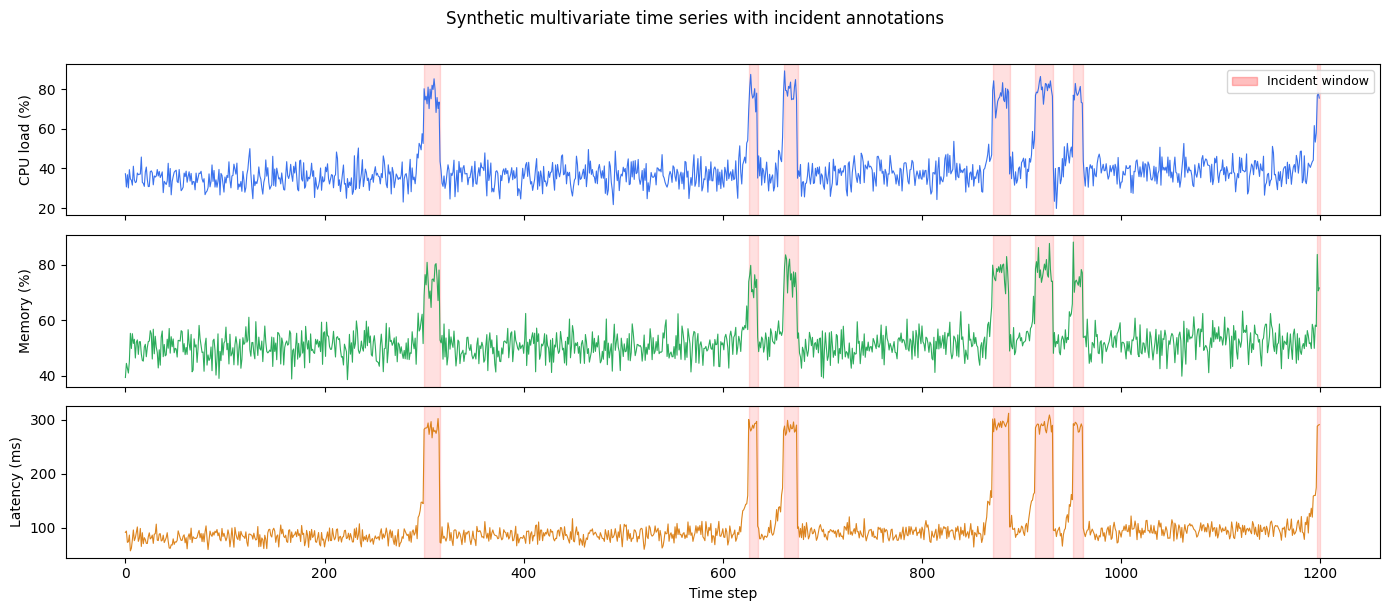

In [130]:
def shade_incident_windows(ax, incident_mask, color="red", alpha=0.12):
  in_window = False
  start = 0
  for i, flag in enumerate(incident_mask):
    if flag and not in_window:
      start, in_window = i, True
    elif not flag and in_window:
      ax.axvspan(start, i, color=color, alpha=alpha)
      in_window = False
  if in_window:
    ax.axvspan(start, len(incident_mask), color=color, alpha=alpha)


fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
metrics = [
  ("cpu", "CPU load (%)", "#2563EB"),
  ("memory", "Memory (%)", "#16A34A"),
  ("latency", "Latency (ms)", "#D97706"),
]

for ax, (col, ylabel, color) in zip(axes, metrics):
  ax.plot(df.index, df[col], color=color, lw=0.8, alpha=0.9)
  ax.set_ylabel(ylabel, fontsize=10)
  shade_incident_windows(ax, df["incident_flag"].values)

inc_patch = mpatches.Patch(color="red", alpha=0.25, label="Incident window")
axes[0].legend(handles=[inc_patch], loc="upper right", fontsize=9)
axes[-1].set_xlabel("Time step")
fig.suptitle("Synthetic multivariate time series with incident annotations", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Sliding-window label construction

For each time step t, the label y[t] = 1 if any incident step exists in [t+1, t+H].

This is the "pre-incident alert" label — the model is rewarded for raising an alert before the incident starts, not just during it.

In [131]:
def make_horizon_labels(incident_mask: np.ndarray, horizon: int) -> np.ndarray:
  n = len(incident_mask)
  labels = np.zeros(n, dtype=int)
  # cumulative sum trick: count incidents in the next horizon steps
  cum = np.concatenate([[0], np.cumsum(incident_mask)])
  for t in range(n):
    end = min(t + horizon + 1, n)
    labels[t] = int((cum[end] - cum[t + 1]) > 0)
  return labels


horizon_labels = make_horizon_labels(df["incident_flag"].values, H)

n_pos = horizon_labels.sum()
print(f"Positive samples (incident in next {H} steps): {n_pos}  ({n_pos/len(horizon_labels)*100:.1f}%)")
print(f"Negative samples : {len(horizon_labels) - n_pos}")

Positive samples (incident in next 10 steps): 150  (12.5%)
Negative samples : 1050


---
## 5. Feature extraction

Each window X[t-W+1 … t] of shape (W x 3) is compressed to a 27-dimensional feature vector.

Per channel (cpu, memory, latency), 9 statistics are extracted:

- last: value at the most recent step
- mean: window mean
- std: window standard deviation
- min/max: extremes in the window
- range: max - min
- slope: linear trend (OLS slope over the window)
- delta_3: last - value three steps ago
- z_score: (last - mean) / std - how far current value is from recent baseline

In [132]:
CHANNELS = ["cpu", "memory", "latency"]
STAT_NAMES = ["last", "mean", "std", "min", "max", "range", "slope", "delta_3", "z_score"]
FEATURE_COLS = [f"{ch}_{st}" for ch in CHANNELS for st in STAT_NAMES]

def window_features(window: np.ndarray) -> np.ndarray:
  feats = []
  xs = np.arange(len(window), dtype=float) # for slope computation
  x_mean = xs.mean()
  ss_xx = ((xs - x_mean) ** 2).sum()

  for c in range(window.shape[1]):
    series = window[:, c].astype(float)
    mean = series.mean()
    std = series.std() + 1e-8
    slope = ((xs - x_mean) * (series - mean)).sum() / ss_xx

    feats.extend(
      [
        series[-1],
        mean,
        std,
        series.min(),
        series.max(),
        series.max() - series.min(),
        slope,
        series[-1] - series[-4] if len(series) >= 4 else 0.0,
        (series[-1] - mean) / std,
      ]
    )
  return np.array(feats, dtype=np.float32)


def build_dataset(df: pd.DataFrame, labels: np.ndarray, window_size: int):
  values = df[CHANNELS].values

  features, y, t_idx = [], [], []
  for t in range(window_size - 1, len(df)):
    features.append(window_features(values[t - window_size + 1 : t + 1]))
    y.append(labels[t])
    t_idx.append(t)

  return np.stack(features), np.array(y), np.array(t_idx)


X_all, y_all, t_all = build_dataset(df, horizon_labels, W)

print(f"Feature matrix shape : {X_all.shape}")
print(f"Label vector shape   : {y_all.shape}")
print(f"Positive rate        : {y_all.mean()*100:.1f}%")
print(f"Feature names (first 9): {FEATURE_COLS[:9]}")

Feature matrix shape : (1171, 27)
Label vector shape   : (1171,)
Positive rate        : 12.8%
Feature names (first 9): ['cpu_last', 'cpu_mean', 'cpu_std', 'cpu_min', 'cpu_max', 'cpu_range', 'cpu_slope', 'cpu_delta_3', 'cpu_z_score']


---
## 6. Train / val / test split

Since shuffling creates temporal leakage (e.g. a validation window could contain steps that appear earlier in a training window, exposing future information to the model), windows must be split by time and never be shuffled.

In [133]:
n_total = len(X_all)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * (TRAIN_FRAC + VAL_FRAC))

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val, y_val = X_all[n_train:n_val], y_all[n_train:n_val]
X_test, y_test = X_all[n_val:], y_all[n_val:]

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Train : {len(X_train):4d} samples  |  pos={y_train.mean()*100:.1f}%")
print(f"Val   : {len(X_val):4d} samples  |  pos={y_val.mean()*100:.1f}%")
print(f"Test  : {len(X_test):4d} samples  |  pos={y_test.mean()*100:.1f}%")
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (neg/pos ratio in train set)")

Train :  819 samples  |  pos=8.1%
Val   :  176 samples  |  pos=40.9%
Test  :  176 samples  |  pos=6.8%
scale_pos_weight = 11.41  (neg/pos ratio in train set)


---
## 7. Model training

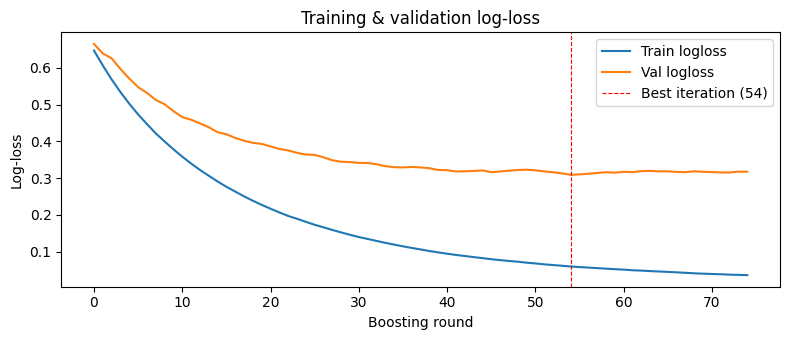

Best iteration     : 54
Val log-loss (best): 0.3089


In [134]:
params = {**XGB_PARAMS, "scale_pos_weight": scale_pos_weight}

model = xgb.XGBClassifier(
  **params,
  early_stopping_rounds=20,
  use_label_encoder=False,
)

model.fit(
  X_train,
  y_train,
  eval_set=[(X_train, y_train), (X_val, y_val)],
  verbose=False,
)

results = model.evals_result()
tr_loss = results["validation_0"]["logloss"]
val_loss = results["validation_1"]["logloss"]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(tr_loss, label="Train logloss", lw=1.5)
ax.plot(val_loss, label="Val logloss", lw=1.5)
best_iter = model.best_iteration
ax.axvline(best_iter, color="red", lw=0.8, ls="--", label=f"Best iteration ({best_iter})")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Log-loss")
ax.set_title("Training & validation log-loss")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best iteration     : {best_iter}")
print(f"Val log-loss (best): {val_loss[best_iter]:.4f}")

---
## 8. Threshold optimisation on the validation dataset

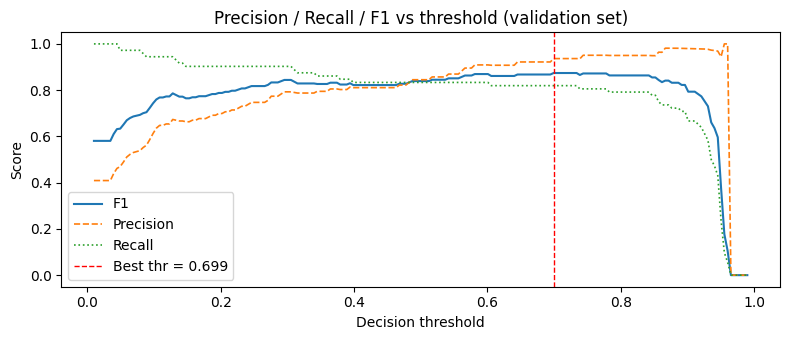

Optimal threshold (val F1): 0.699
Val F1 at best threshold  : 0.874


In [135]:
val_probs = model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
f1s, precs, recs = [], [], []
for thr in thresholds:
  preds = (val_probs >= thr).astype(int)
  f1s.append(f1_score(y_val, preds, zero_division=0))
  precs.append(precision_score(y_val, preds, zero_division=0))
  recs.append(recall_score(y_val, preds, zero_division=0))

f1s = np.array(f1s)
precs = np.array(precs)
recs = np.array(recs)

best_idx = int(f1s.argmax())
best_thr = thresholds[best_idx]
best_f1_val = f1s[best_idx]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(thresholds, f1s, label="F1", lw=1.5)
ax.plot(thresholds, precs, label="Precision", lw=1.2, ls="--")
ax.plot(thresholds, recs, label="Recall", lw=1.2, ls=":")
ax.axvline(best_thr, color="red", lw=1.0, ls="--", label=f"Best thr = {best_thr:.3f}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs threshold (validation set)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Optimal threshold (val F1): {best_thr:.3f}")
print(f"Val F1 at best threshold  : {best_f1_val:.3f}")

---
## 9. Model evaluation

All metrics below are computed on the test dataset only.

In [136]:
test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_thr).astype(int)

auc_roc = roc_auc_score(y_test, test_probs)
auc_pr = average_precision_score(y_test, test_probs)

print("=" * 55)
print("TEST SET RESULTS")
print("=" * 55)
print(classification_report(y_test, test_preds, target_names=["No incident", "Incident"]))
print(f"ROC-AUC  : {auc_roc:.4f}")
print(f"AUC-PR   : {auc_pr:.4f}")
print(f"Threshold: {best_thr:.3f}")

TEST SET RESULTS
              precision    recall  f1-score   support

 No incident       0.96      0.99      0.98       164
    Incident       0.83      0.42      0.56        12

    accuracy                           0.95       176
   macro avg       0.90      0.71      0.77       176
weighted avg       0.95      0.95      0.95       176

ROC-AUC  : 0.9456
AUC-PR   : 0.7558
Threshold: 0.699


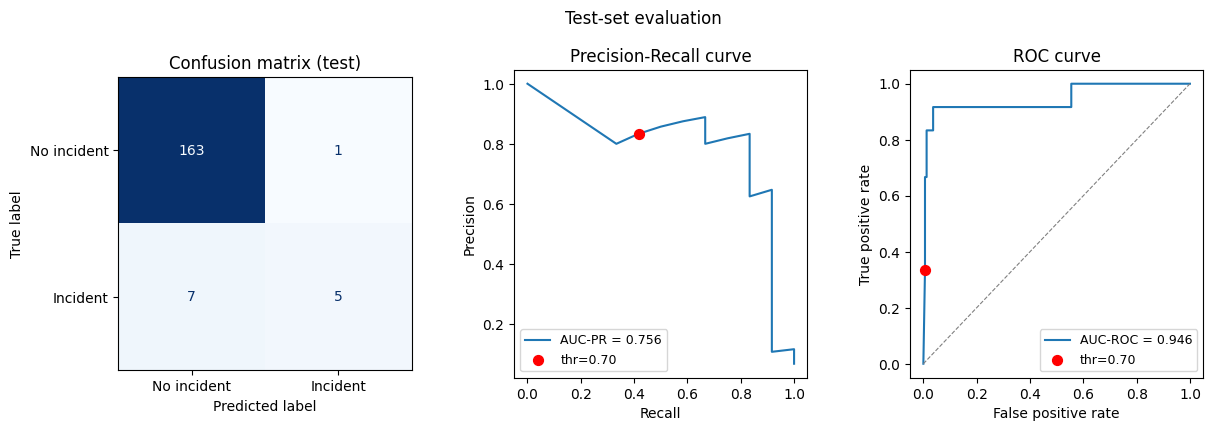

In [137]:
fig = plt.figure(figsize=(14, 4))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

# Confusion matrix
ax0 = fig.add_subplot(gs[0])
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["No incident", "Incident"])
disp.plot(ax=ax0, colorbar=False, cmap="Blues")
ax0.set_title("Confusion matrix (test)")
ax0.grid(False)

# PR curve
ax1 = fig.add_subplot(gs[1])
prec_curve, rec_curve, pr_thrs = precision_recall_curve(y_test, test_probs)
ax1.plot(rec_curve, prec_curve, lw=1.5, label=f"AUC-PR = {auc_pr:.3f}")
# mark chosen threshold
idx_thr = np.argmin(np.abs(pr_thrs - best_thr))
ax1.scatter(
  rec_curve[idx_thr],
  prec_curve[idx_thr],
  color="red",
  zorder=5,
  s=50,
  label=f"thr={best_thr:.2f}",
)
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.set_title("Precision-Recall curve")
ax1.legend(fontsize=9)

# ROC curve
ax2 = fig.add_subplot(gs[2])
fpr, tpr, roc_thrs = roc_curve(y_test, test_probs)
ax2.plot(fpr, tpr, lw=1.5, label=f"AUC-ROC = {auc_roc:.3f}")
ax2.plot([0, 1], [0, 1], ls="--", color="grey", lw=0.8)
# mark threshold
idx_roc = np.argmin(np.abs(roc_thrs - best_thr))
ax2.scatter(
  fpr[idx_roc],
  tpr[idx_roc],
  color="red",
  zorder=5,
  s=50,
  label=f"thr={best_thr:.2f}",
)
ax2.set_xlabel("False positive rate")
ax2.set_ylabel("True positive rate")
ax2.set_title("ROC curve")
ax2.legend(fontsize=9)

fig.suptitle("Test-set evaluation", fontsize=12, y=1.03)
plt.show()

# Analyzing the results

---
## 10. Feature importance

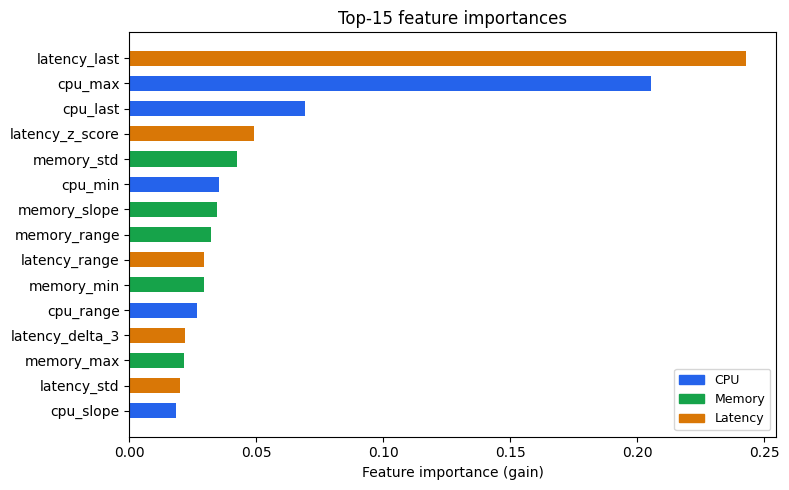

        feature     gain
   latency_last 0.242710
        cpu_max 0.205345
       cpu_last 0.069232
latency_z_score 0.049072
     memory_std 0.042322
        cpu_min 0.035383
   memory_slope 0.034361
   memory_range 0.032239
  latency_range 0.029415
     memory_min 0.029161
      cpu_range 0.026750
latency_delta_3 0.021756
     memory_max 0.021540
    latency_std 0.019782
      cpu_slope 0.018385


In [138]:
importance_df = (
  pd.DataFrame({"feature": FEATURE_COLS, "gain": model.feature_importances_})
  .sort_values("gain", ascending=False)
  .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [
  "#2563EB" if "cpu" in feature else "#16A34A" if "memory" in feature else "#D97706"
  for feature in importance_df["feature"]
]
ax.barh(
  importance_df["feature"][::-1],
  importance_df["gain"][::-1],
  color=colors[::-1],
  height=0.6,
)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top-15 feature importances")

legend_patches = [
  mpatches.Patch(color="#2563EB", label="CPU"),
  mpatches.Patch(color="#16A34A", label="Memory"),
  mpatches.Patch(color="#D97706", label="Latency"),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

---
## 11. Alert lead-time analysis

In this cell for true positive alerts we analyze how many steps before the incident onset does the model raise the alert. The higher this number is the more time will be before incident happens.

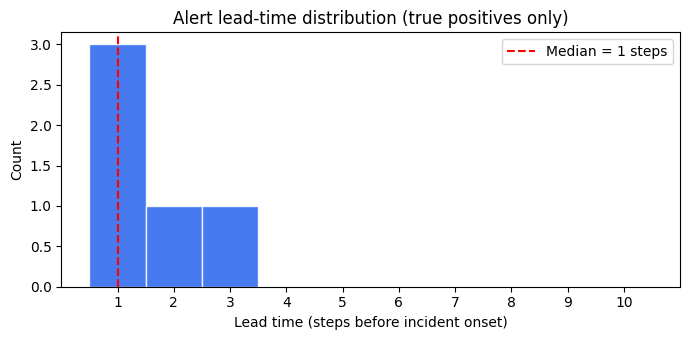

Median lead time : 1 steps
Mean lead time   : 1.6 steps
Min / Max        : 1 / 3 steps


In [139]:
t_test = t_all[n_val:]

lead_times = []
for i, t in enumerate(t_test):
  if test_preds[i] == 1 and y_test[i] == 1:
    for offset in range(1, H + 1):
      if t + offset < len(df) and df["incident_flag"].iloc[t + offset] == 1:
        lead_times.append(offset)
        break

if lead_times:
  lead_times = np.array(lead_times)
  fig, ax = plt.subplots(figsize=(7, 3.5))
  ax.hist(
    lead_times,
    bins=range(1, H + 2),
    edgecolor="white",
    color="#2563EB",
    alpha=0.85,
    align="left",
  )
  ax.axvline(
    np.median(lead_times),
    color="red",
    ls="--",
    label=f"Median = {np.median(lead_times):.0f} steps",
  )
  ax.set_xlabel("Lead time (steps before incident onset)")
  ax.set_ylabel("Count")
  ax.set_title("Alert lead-time distribution (true positives only)")
  ax.set_xticks(range(1, H + 1))
  ax.legend()
  plt.tight_layout()
  plt.show()
  print(f"Median lead time : {np.median(lead_times):.0f} steps")
  print(f"Mean lead time   : {np.mean(lead_times):.1f} steps")
  print(f"Min / Max        : {lead_times.min()} / {lead_times.max()} steps")
else:
  print("No true positives found in test set -- try lowering the threshold.")

---
## 12. Simulated live inference

This cell mimics production inference: a new window arrives, features are extracted, and the model returns a probability score and a binary alert.

In [140]:
def predict_window(df_recent: pd.DataFrame, threshold: float = best_thr) -> dict:
  if len(df_recent) < W:
    raise ValueError(f"Need at least {W} rows, got {len(df_recent)}")

  window = df_recent[CHANNELS].values[-W:]
  feats = window_features(window).reshape(1, -1)
  prob = float(model.predict_proba(feats)[0, 1])

  return {
    "probability": round(prob, 4),
    "alert": bool(prob >= threshold),
    "threshold": round(threshold, 4),
  }


normal_window = pd.DataFrame(
  {
    "cpu": rng.normal(35, 5, W),
    "memory": rng.normal(50, 4, W),
    "latency": rng.normal(80, 10, W),
  }
)
result_normal = predict_window(normal_window)
print("Normal conditions  :", result_normal)

spike_window = normal_window.copy()
spike_window.iloc[-8:, 0] += 45
spike_window.iloc[-8:, 2] += 250
result_spike = predict_window(spike_window)
print("Pre-incident spike :", result_spike)

Normal conditions  : {'probability': 0.0344, 'alert': False, 'threshold': np.float64(0.6994)}
Pre-incident spike : {'probability': 0.667, 'alert': False, 'threshold': np.float64(0.6994)}


---
## 13. Results summary

In [141]:
summary = pd.DataFrame(
  {
    "Metric": [
      "Precision",
      "Recall",
      "F1 score",
      "ROC-AUC",
      "AUC-PR",
      "Alert threshold",
      "Positive rate (test)",
      "Features",
      "Window W",
      "Horizon H",
    ],
    "Value": [
      f"{precision_score(y_test, test_preds, zero_division=0):.3f}",
      f"{recall_score(y_test, test_preds, zero_division=0):.3f}",
      f"{f1_score(y_test, test_preds, zero_division=0):.3f}",
      f"{auc_roc:.4f}",
      f"{auc_pr:.4f}",
      f"{best_thr:.3f}",
      f"{y_test.mean()*100:.1f}%",
      str(len(FEATURE_COLS)),
      str(W),
      str(H),
    ],
  }
)
print(summary.to_string(index=False))

              Metric  Value
           Precision  0.833
              Recall  0.417
            F1 score  0.556
             ROC-AUC 0.9456
              AUC-PR 0.7558
     Alert threshold  0.699
Positive rate (test)   6.8%
            Features     27
            Window W     30
           Horizon H     10
